Пусть $$pV = \nu RT,$$
где $R \approx 8.31$ - универсальная газовая постоянная, $Дж/(моль \cdot K)$

Так как $N = N_A \cdot n$, где $N_A$ - постоянная Авогадро, $n$ - концентрация частиц, $V = N / n$, то:
$$n = \frac{p}{kT},$$
где $k$ - постоянная Больцмана $1.38 \cdot 10^{-23}, Дж/К$.

In [1]:
import numpy as np

from spectrumlab.lines import Line
from spectrumlab.types import Kelvin, Meter

from spectrumlab_spectral_line.estimators import LineShapeEstimator, LineShapeEstimatorConfig


PRESSURE = 1e+5  # in Pa
BOLTZMANN = 1.38e-23  # in J/K

In [2]:
def estimate_n(T: Kelvin) -> float:
    """Оценить концентрацию частиц при атм. давление."""
    return PRESSURE / (BOLTZMANN * T)

tolerance = 1e-9
assert np.abs(estimate_n(300)/estimate_n(6000) - 20) < tolerance

In [3]:
def estimate_sigma(free_path: Meter, T: Kelvin) -> float:
    """Оценить эффективное сечение соударения частиц при атм. давление."""

    return 1.36e-28 * T / free_path

In [4]:
sigma_hat = estimate_sigma(
    free_path=1e-7,
    T=800,
)

print(fr'$/hat{{/sigma}}$: {sigma_hat}')

$/hat{/sigma}$: 1.088e-18


Zn 328.23:
	Natural broadening: 0.006 [pm]
	Doppler broadening: 0.822 [pm]
	Collision broadening: 2.192 [pm]
	FWHM of the shape (by formula): 2.4662 [pm].


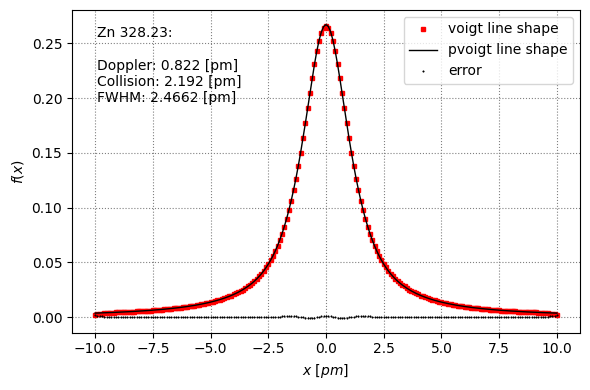

In [5]:
estimator = LineShapeEstimator(
    config=LineShapeEstimatorConfig(
        temperature=800,
        buffer='Ne',
    ),
)

shape = estimator.fit(
    line=Line('Zn', 328.23),
    verbose=True,
    show=True,
    # save=True,
)

Ag 338.289:
	Natural broadening: 0.006 [pm]
	Doppler broadening: 1.206 [pm]
	Collision broadening: 0.926 [pm]
	FWHM of the shape (by formula): 1.7549 [pm].


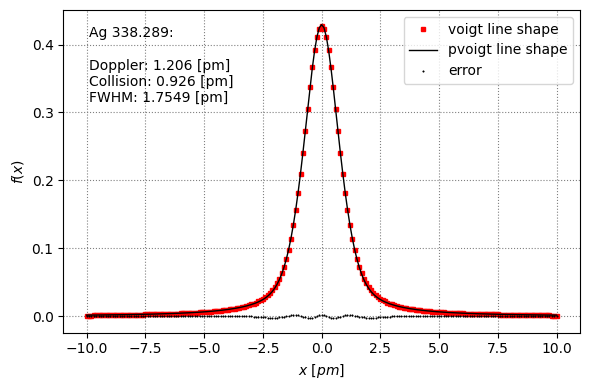

In [6]:
estimator = LineShapeEstimator(
    config=LineShapeEstimatorConfig(
        temperature=2400 + 273.15,
        buffer='Ar',
    ),
)

shape = estimator.fit(
    line=Line('Ag', 338.289),
    verbose=True,
    show=True,
    # save=True,
)